<a href="https://colab.research.google.com/github/liamscanlon5/undergrad_ml_assignments/blob/main/LiamScanlon01_assignment_wrangling_and_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Wrangling and EDA
### Foundations of Machine Learning

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `airbnb_NYC.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? For the remaining missing values, replace the `np.nan/None` values with the label `Missing`.
3. Dummy variable: For `metabric.csv`, convert the `Overall Survival Status` variable into a dummy/binary variable, taking the value 0 if the patient is deceased and 1 if they are living.
4. Missing values: For `airbnb_NYC.csv`, determine how many missing values of `Review Scores Rating` there are. Create a new variable, in which you impute the median score for non-missing observations to the missing ones. Why might this bias or otherwise negatively impact your results?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('airbnb_NYC.csv', encoding='latin1')
df.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


In [3]:
# Remove currency symbols and commas
df['Price_clean'] = df['Price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

# Convert to numeric
df['Price_clean'] = pd.to_numeric(df['Price_clean'], errors='coerce')

# Count the missing values
missing_count = df['Price_clean'].isna().sum()


# Return
print(f"Total missing values in Price: {missing_count}")
print(df[['Price', 'Price_clean']].head(10)) # Compare the original vs cleaned

Total missing values in Price: 0
  Price  Price_clean
0   145          145
1    37           37
2    28           28
3   199          199
4   549          549
5   149          149
6   250          250
7    90           90
8   270          270
9   290          290


In [4]:
# Look at the top 10 most expensive listings to ensure commas were removed
print(df[['Price', 'Price_clean']].sort_values(by='Price_clean', ascending=False).head(10))

        Price  Price_clean
23927  10,000        10000
4002    8,000         8000
17900   6,500         6500
2405    5,999         5999
7550    5,000         5000
1275    5,000         5000
24136   5,000         5000
15633   5,000         5000
3483    4,750         4750
17466   4,500         4500


To clean the Price variable, I first removed characters like commas and dollar signs because their presence in numbers over $999 causes Python to treat the data as text strings rather than numeric values. I then applied pd.to_numeric() with the errors='coerce' argument, which ensures that any remaining non-numeric entries are safely converted to NaN instead of crashing the script. Based on the output of my code, I ended up with 0 missing values in the cleaned column. These choices were made to ensure the column is stored as a float data type, which is necessary for performing mathematical operations like calculating the average price.

In [5]:
# Q1.2

df_mn = pd.read_csv('mn_police_use_of_force.csv')
df_mn.head()

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [6]:
# Calculate missing proportion
prop_missing = df_mn['subject_injury'].isnull().mean()
print(f"Proportion of missing values in subject_injury: {prop_missing:.2%}")

# Standardize 'Yes'/'No' values
df_mn['subject_injury_clean'] = df_mn['subject_injury'].replace({
    'YES': 'Yes', 'NO': 'No', 1: 'Yes', 0: 'No', 'True': 'Yes', 'False': 'No'
})

# Replace NAs with 'Missing'
df_mn['subject_injury_clean'] = df_mn['subject_injury_clean'].fillna('Missing')

# print crosstab
final_ctab = pd.crosstab(df_mn['force_type'], df_mn['subject_injury_clean'])
print("\nFinal Cross-tabulation (Force Type vs Injury):")
print(final_ctab)

Proportion of missing values in subject_injury: 76.19%

Final Cross-tabulation (Force Type vs Injury):
subject_injury_clean         Missing    No   Yes
force_type                                      
Baton                              2     0     2
Bodily Force                    7051  1093  1286
Chemical Irritant               1421   131    41
Firearm                            0     2     0
Gun Point Display                 27    33    44
Improvised Weapon                 74    34    40
Less Lethal                       87     0     0
Less Lethal Projectile             0     1     2
Maximal Restraint Technique      170     0     0
Police K9 Bite                    31     2    44
Taser                            985   150   172


The data shows a clear pattern where reporting consistency depends on the severity of force. Actions like firearm use have zero missing entries while routine "Bodily Force" accounts for over 7,000 missing values. This discrepancy suggests that documentation is often neglected in physical scuffles compared to incidents involving specialized weapons where strict reporting is mandatory. It is very clear when a gun is fired or not, but it is not clear what counts as Bodily Force, or the severity of the Bodily Force. This breakdown means that the "Missing" label serves as a signal for lower-intensity force categories.

In [7]:
# Q1.3
df_met = pd.read_csv('metabric.csv')
df_met.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Chemotherapy,Hormone Therapy,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,Radio Therapy,TMB (nonsynonymous),Tumor Size,Tumor Stage
0,43.19,BREAST CONSERVING,Breast Cancer,NO,YES,0.0,2.0,4.020,84.633333,0:LIVING,YES,2.615035,10.0,1.0
1,48.87,MASTECTOMY,Breast Cancer,YES,YES,1.0,2.0,4.030,163.700000,1:DECEASED,NO,2.615035,15.0,2.0
2,47.68,MASTECTOMY,Breast Cancer,YES,YES,3.0,1.0,4.050,164.933333,0:LIVING,YES,1.307518,25.0,2.0
3,76.97,MASTECTOMY,Breast Cancer,YES,YES,8.0,2.0,6.080,41.366667,1:DECEASED,YES,2.615035,40.0,2.0
4,78.77,MASTECTOMY,Breast Cancer,NO,YES,0.0,4.0,4.062,7.800000,1:DECEASED,YES,5.230071,31.0,4.0


In [8]:
# Check the unique values
print("Unique values before cleaning:", df_met['Overall Survival Status'].unique())

# Create the dummy variable
# Value 0 if deceased, 1 if living
df_met['survival_dummy'] = df_met['Overall Survival Status'].map({
    '1:DECEASED': 0,
    '0:LIVING': 1
})

# Verify the transformation
print("\nTransformation Check:")
print(df_met[['Overall Survival Status', 'survival_dummy']].head())

Unique values before cleaning: ['0:LIVING' '1:DECEASED']

Transformation Check:
  Overall Survival Status  survival_dummy
0                0:LIVING               1
1              1:DECEASED               0
2                0:LIVING               1
3              1:DECEASED               0
4              1:DECEASED               0


In [9]:
# Q1.4: Back to AirBNB csv

# Count missing values
missing_reviews = df['Review Scores Rating'].isnull().sum()
print(f"Missing Review Scores: {missing_reviews}")

# Calculate the median of the existing scores
review_median = df['Review Scores Rating'].median()

# Create the new variable with imputed values
df['Review_Scores_Imputed'] = df['Review Scores Rating'].fillna(review_median)

# Verification
print(f"Median used for imputation: {review_median}")
print(f"Missing values in new column: {df['Review_Scores_Imputed'].isnull().sum()}")


Missing Review Scores: 8323
Median used for imputation: 94.0
Missing values in new column: 0


Imputing the median reduces the natural variance of the dataset by clustering scores around a single value. This can mislead an ML model into thinking the data is more consistent than it actually is. This approach overestimates the quality of unrated or new listings because assigning them an average score ignores the possibility that they are missing reviews due to poor performance. This can distort correlations between review scores and other variables like price, and this can lead to less accurate predictions in the final analysis.

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work. What does work?
2. Drop any columns that do not contain data.
3. What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.
4. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
5. Clean the Age variable and make a histogram of the ages of the victims.
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?

In [10]:
# Because the shark attack file is compatible as an Excel file, I need to read it by using the Excel Engine
# Install the excel engine
!pip install openpyxl

df_shark = pd.read_excel('GSAF5.xlsx')
df_shark.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,...,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,...,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,...,1.7m Seven Gill shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Manually drop the columns that don't contain attack data
cols_to_drop = ['pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
                'original order', 'Unnamed: 21', 'Unnamed: 22']

# Use errors='ignore' in case one was already dropped
df_shark = df_shark.drop(columns=cols_to_drop, errors='ignore')

# Drop any remaining rows that are empty
df_shark = df_shark.dropna(how='all')

print(df_shark.columns)

df_shark.head()

Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source'],
      dtype='object')


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,Right thigh and lower leg stripped of flesh,Y,?,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,No injury shark knocked man of his board,N,1100hrs,Unknown,Bob Myatt GSAF
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,Puncture wounds to right knee,N,1815hrs,1.7m Seven Gill shark,Bob Myatt GSAF
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,Minor cuts and abrasions,N,0830hrs,Bull shark,Bob Myatt GSAF
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,None reported damage to board,N,1145hrs,Bull shark,Andy Currie


Q2.3

An observation in this dataset represents a single documented incident of a shark encounter involving a human victim at a specific time and location. This definition is essential because it allows you to treat each row as a unique event and identify potential duplicates or non-attack entries like boat accidents.

The range of values after filtering is 1940 to 2026.


<Axes: title={'center': 'Shark Attacks Since 1940'}, xlabel='Year_clean'>

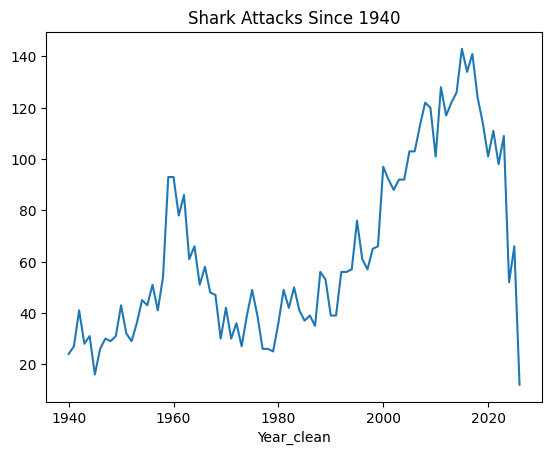

In [12]:
# Q2.4
# Convert Year to numeric, turning text/errors into NaN
df_shark['Year_clean'] = pd.to_numeric(df_shark['Year'], errors='coerce')

# Filter for attacks since 1940
df_recent = df_shark[df_shark['Year_clean'] >= 1940].copy()

# Check the range
year_min = df_recent['Year_clean'].min()
year_max = df_recent['Year_clean'].max()

print(f"The range of values after filtering is {int(year_min)} to {int(year_max)}.")

# Count attacks per year to see the trend
attacks_by_year = df_recent['Year_clean'].value_counts().sort_index()
attacks_by_year.plot(kind='line', title='Shark Attacks Since 1940')

You can see that attacks have swayed but steadily increased over time. However, a steep dropoff has made the 1940 shark attacks and the recent years shark attacks very similar.

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-4171181906.py:3: SyntaxWarning: invalid escape sequence '\d'
  df_recent['Age_clean'] = df_recent['Age'].astype(str).str.extract('(\d+)').astype(float)


Number of rows where Age couldn't be cleaned: 1825


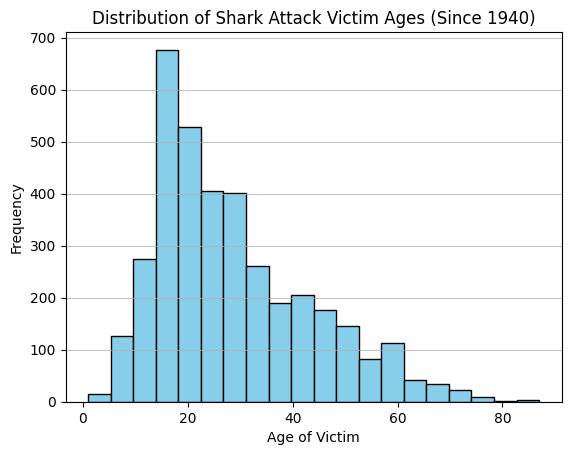

In [13]:
# Q2.5
# Clean the Age variable
df_recent['Age_clean'] = df_recent['Age'].astype(str).str.extract('(\d+)').astype(float)

# Check for missing values created
missing_ages = df_recent['Age_clean'].isnull().sum()
print(f"Number of rows where Age couldn't be cleaned: {missing_ages}")

# Create the Histogram
plt.hist(df_recent['Age_clean'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Shark Attack Victim Ages (Since 1940)')
plt.xlabel('Age of Victim')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [14]:
# Q2.6
# Create a mapping to condense the many categories into three
type_mapping = {
    'Unprovoked': 'Unprovoked',
    'Provoked': 'Provoked',
    'Questionable': 'Unknown',
    'Invalid': 'Unknown',
    'Sea Disaster': 'Unknown',
    'Boat': 'Unknown',
    'Boating': 'Unknown',
    'Boatomg': 'Unknown'
}

# Apply the mapping and fill any remaining NaNs as 'Unknown'
df_recent['Type_clean'] = df_recent['Type'].map(type_mapping).fillna('Unknown')

# Calculate proportions
type_proportions = df_recent['Type_clean'].value_counts(normalize=True)
unprovoked_prop = type_proportions.get('Unprovoked', 0)

print(f"Proportions of each type:\n{type_proportions}")
print(f"\nProportion of attacks that are Unprovoked: {unprovoked_prop:.2%}")

Proportions of each type:
Type_clean
Unprovoked    0.744854
Unknown       0.161069
Provoked      0.094077
Name: proportion, dtype: float64

Proportion of attacks that are Unprovoked: 74.49%


In [15]:
# Q2.7

# Create a mapping for the Fatal column
# Use .str.strip().str.upper() first to catch lowercase 'y' or trailing spaces
df_recent['Fatal_clean'] = df_recent['Fatal Y/N'].str.strip().str.upper()

fatal_mapping = {
    'Y': 'Y',
    'N': 'N',
    'UNKNOWN': 'Unknown',
    'U': 'Unknown',
    'M': 'Unknown',
    '2017': 'Unknown'
}

# Apply mapping and fill anything else (like NaNs) as 'Unknown'
df_recent['Fatal_clean'] = df_recent['Fatal_clean'].map(fatal_mapping).fillna('Unknown')

# Verify the results
print(df_recent['Fatal_clean'].value_counts())

Fatal_clean
N          4246
Y           830
Unknown     462
Name: count, dtype: int64


In [16]:
# Q2.8

# Create a cross-tab showing percentages for each attack type
fatality_comparison = pd.crosstab(df_recent['Type_clean'], df_recent['Fatal_clean'], normalize='index')

# Display as percentages
print(fatality_comparison * 100)

Fatal_clean          N    Unknown          Y
Type_clean                                  
Provoked     95.969290   1.727447   2.303263
Unknown      41.255605  44.843049  13.901345
Unprovoked   81.890909   1.284848  16.824242


This table shows us a couple things. First off, unprovoked Attacks are significantly more dangerous, with a fatality rate of approximately 16.82%, while provoked attacks have a fatality rate of 2.3%. A vast majority of provoked attacks are Non-fatal.

The Unknown Group has the highest level of uncertainty, with nearly 44.84% of its fatality data marked as "Unknown". This is likely because these records (such as sea disasters or boat accidents) often lack clear individual outcomes.

I am a little shocked by these outcomes, because it intuitively makes sense that a shark would be more aggressive if it was provoked. However, another way to look at it is that dangerous sharks are dangerous no matter if they are provoked or not. One of the leading causes of shark attacks is that sharks mistakenly identify humans for injured seals/sea lions. This would be classified as an unprovoked attack, and I wouldn't be surprised if that is what is causing these percentages. Provoked attacks may also just be defensive warning nips or bites triggered by direct human interference, which are much less likely to be life-threatening.

**Q3.** Open the "tidy_data.pdf" document available in `https://github.com/ds4e/wrangling`, which is a paper called *Tidy Data* by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?
  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
  4. Read Section 2.2. How does Wickham define values, variables, and observations?
  5. How is "Tidy Data" defined in section 2.3?
  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?
  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

Q3 Answers

1. This paper is about how to make data cleaning as easy and effective as possible by utilizing a method called "data tidying". It describes tidy datasets as easy to manipulate, and its specific structure helps analysis.

2. The "tidy data standard" is a framework for organizing data values within a dataset to make cleaning, exploration, and analysis more efficient. The standard is designed to simplify the development of data analysis tools by providing a consistent structure, which reduces the need for translation between different software.

3. The sentence "Like families, tidy datasets are all alike but every messy dataset is messy in its own way" means that tidy datasets provide a standardized way to turn every messy dataset into having a similar-looking layout and meaning. The sentence "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general" means that while identifying data components often feels intuitive when looking at a specific dataset, creating a universal mathematical definition that applies across all possible contexts is complex. This ambiguity occurs because meanings of variables and observations can shift depending on the specific goals of the analysis or the structure of the domain problem.

4. Wickham says that a collection of **values** is a dataset. Every **value** belongs to a **variable** and an **observation**. A **variable** is all values that measure the same underlying attribute across units, like height or temperature. An **observation** contains all values measured on the same unit across attributes, like a person or a day.

5. In section 2.3, "Tidy Data" is defined as a standard way of mapping the meaning of a dataset to its structure. In tidy data:
- Each variable forms a column
- Each observation forms a row
- Each type of observational unity forms a table

6. The 5 most common problems with messy datasets are:
- Column headers are values, not variable names.
- Multiple variables are stored in one column.
- Variables are stored in both rows and columns.
- Multiple types of observational units are stored in the same table.
- A single observational unit is stored in multiple tables

The data in Table 4 are messy because values (income) are being used as column headers, frequency is spread across 6 columns, and the observations are not clearly in rows. A single row contains multiple observations.

"Melting" a dataset involves stacking a dataset by turning columns into rows. The result of melting is a molten dataset.

7. Table 11 is messy because variables are stored in both rows and columns. Table 12 is tidy and "molten" because each variable has its own column, each observation has its own row, and values are correctly placed.

**Q4.** This question looks at financial transfers from international actors to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going?

For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
5. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions.
6. Which giftors provide the most money, in total?

In [44]:
# Q4.1
df_gifts = pd.read_csv('ForeignGifts_edu.csv')
df_gifts.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


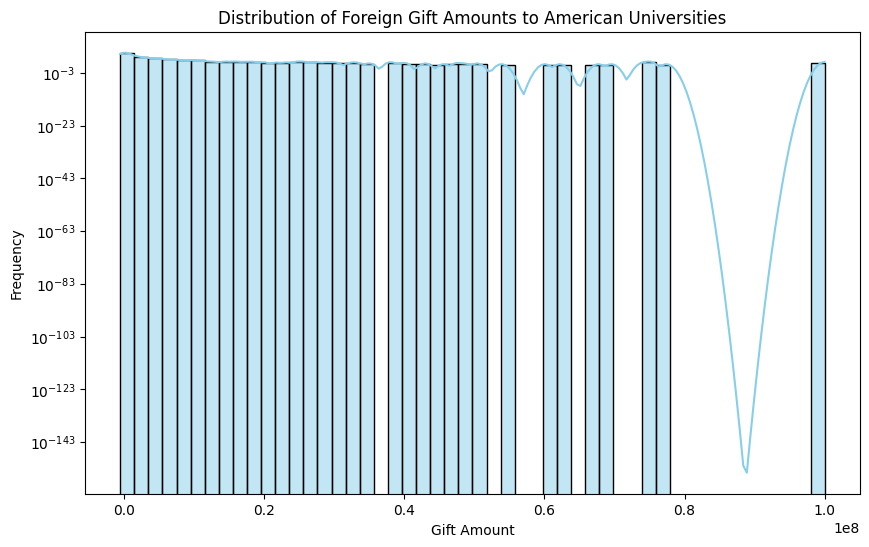

In [25]:
# Q4.2 Create Histogram for Foreign Gift Amount
plt.figure(figsize=(10, 6))
sns.histplot(df_gifts['Foreign Gift Amount'], bins=50, kde=True, color='skyblue')

# Adding labels and title
plt.title('Distribution of Foreign Gift Amounts to American Universities')
plt.xlabel('Gift Amount')
plt.ylabel('Frequency')

# used because data is skewed
plt.yscale('log')

The graph is heavily skewed to the right, which shows that the majority of foreign gifts are relatively small, and only a small handful of gifts are in the upper echelon. The dataset is influenced by high-value outliers reaching up to $100 million. Because of this extreme variance, the mean gift amount is likely much higher than the median.

               Count  Proportion
Gift Type                       
Contract       17274    0.612097
Monetary Gift  10936    0.387513
Real Estate       11    0.000390


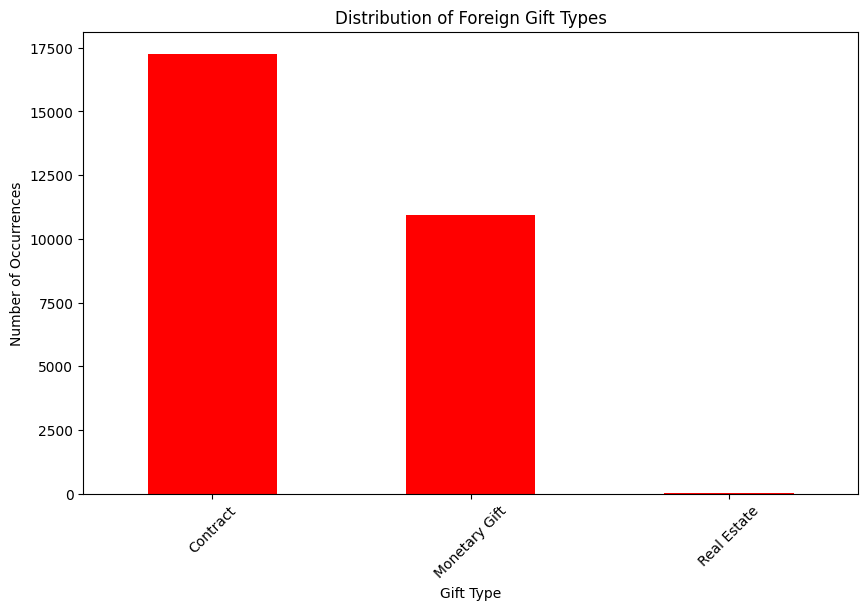

In [33]:
# Q4.3

# Create a value counts table
gift_counts = df_gifts['Gift Type'].value_counts()
gift_proportions = df_gifts['Gift Type'].value_counts(normalize=True)

# Combine into a single table for clarity
gift_summary = pd.DataFrame({
    'Count': gift_counts,
    'Proportion': gift_proportions
})
print(gift_summary)

# Create the visualization and label
plt.figure(figsize=(10, 6))
gift_counts.plot(kind='bar', color='red')
plt.title('Distribution of Foreign Gift Types')
plt.xlabel('Gift Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=45)
plt.show()

61.2% of gifts are Contracts, 38.8% are Monetary Gifts, and 0.039% are Real Estate gifts.

In [38]:
# Q4.4

# Top 15 Countries by Number of Gifts (Count)
top_15_count = df_gifts.groupby('Country of Giftor')['Foreign Gift Amount'].count().sort_values(ascending=False).head(15)

# Top 15 Countries by Total Amount Given (Sum)
top_15_sum = df_gifts.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

# Display the numerical tables
print("Top 15 by Count:\n", top_15_count)
print("\nTop 15 by Total Sum:\n", top_15_sum)

Top 15 by Count:
 Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64

Top 15 by Total Sum:
 Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                24840920

Top 15 Institutions by Total Foreign Funding:
Institution Name
Carnegie Mellon University                       1477922504
Cornell University                               1289937761
Harvard University                                954803610
Massachusetts Institute of Technology             859071692
Yale University                                   613441311
Texas A&M University                              521455050
Johns Hopkins University                          502409595
Northwestern University                           402316221
Georgetown University                             379950511
University of Chicago (The)                       364544338
University of Colorado Boulder                    360173159
Duke University                                   343699498
Brigham Young University                          323509863
Stanford University                               319561362
University of Texas MD Anderson Cancer Center     301527419
Name: Foreign Gift Amount, dtype: int

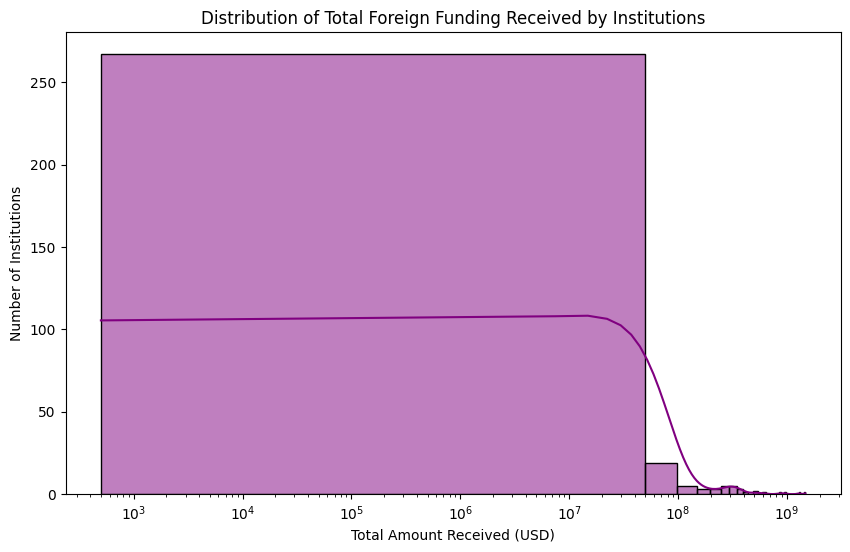

In [45]:
# Q4.5

# Calculate the total amount per institution
inst_totals = df_gifts.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)

# Identify the Top 15 Institutions
top_15_inst = inst_totals.head(15)
print("Top 15 Institutions by Total Foreign Funding:")
print(top_15_inst)

# Create a histogram of total amounts received by all institutions
plt.figure(figsize=(10, 6))

# Log scale for the x-axis because the totals vary widely
sns.histplot(inst_totals, bins=30, kde=True, color='purple')
plt.title('Distribution of Total Foreign Funding Received by Institutions')
plt.xlabel('Total Amount Received (USD)')
plt.ylabel('Number of Institutions')

# Formatting the x-axis to show readable numbers
plt.xscale('log')
plt.show()

The huge block on the left side shows that there are thousands of small gifts and only a few massive ones in the dataset.

In [43]:
# Q4.6

# Group by Giftor Name and sum the amounts
top_giftors = df_gifts.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)

# Display the result
print("Top 15 Giftors by Total Amount Given:")
print(top_giftors)

Top 15 Giftors by Total Amount Given:
Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


3 Qatar Foundations are on the top of the list.

**Q5.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `college_completion.csv` dataset from the US Department of Education. The "relevant" variables for this question are:
  - `level` - Level of institution (4-year, 2-year)
  - `aid_value` - The average amount of student aid going to undergraduate recipients
  - `control` - Public, Private not-for-profit, Private for-profit
  - `grad_100_value` - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)

1. Load the `college_completion.csv` data with Pandas.
2. How many observations and variables are in the data? Use `.head()` to examine the first few rows of data.
3. Cross tabulate `control` and `level`. Describe the patterns you see in words.
4. For `grad_100_value`, create a kernel density plot and describe table. Now condition on `control`, and produce a kernel density plot and describe tables for each type of institutional control. Which type of institution appear to have the most favorable graduation rates?
5. Make a scatterplot of `grad_100_value` by `aid_value`, and compute the covariance and correlation between the two variables. Describe what you see. Now make the same plot and statistics, but conditioning on `control`. Describe what you see. For which kinds of institutions does aid seem to vary positively with graduation rates?

In [48]:
# Q5.1 and 5.2
df_college = pd.read_csv('college_completion.csv')
df_college.head()

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


In [51]:
print(df_college.shape)

(3798, 63)


There are 63 variables (columns) and 3798 observations (rows).

In [53]:
# Q5.3
# Create the cross-tabulation table
cross_tab = pd.crosstab(df_college['control'], df_college['level'])

# Display the table
print(cross_tab)

level                   2-year  4-year
control                               
Private for-profit         465     527
Private not-for-profit      68    1180
Public                     926     632


The largest category in this dataset is Private not-for-profit 4-year institutions, with 1,180 occurrences. There is a very strong correlation because if an institution is a private non-profit, it is overwhelmingly likely to be a 4-year university rather than a 2-year college.

The pattern for Public institutions is the opposite of the private not-for-profit sector. Public institutions are significantly more likely to be 2-year colleges (926 occurrences) than 4-year universities (632 occurences). This reflects the American community college system, which is primarily public-funded.

Private for-profit colleges have the most balanced levels, showing that there is not a masive gap between the 2-year and 4-year offerings.

The table overall shows that the 4-year degree space is dominated by private not-for-profit traditional universities, while the 2-year degree space is primarily the domain of public community colleges or online schools (private for-profit).

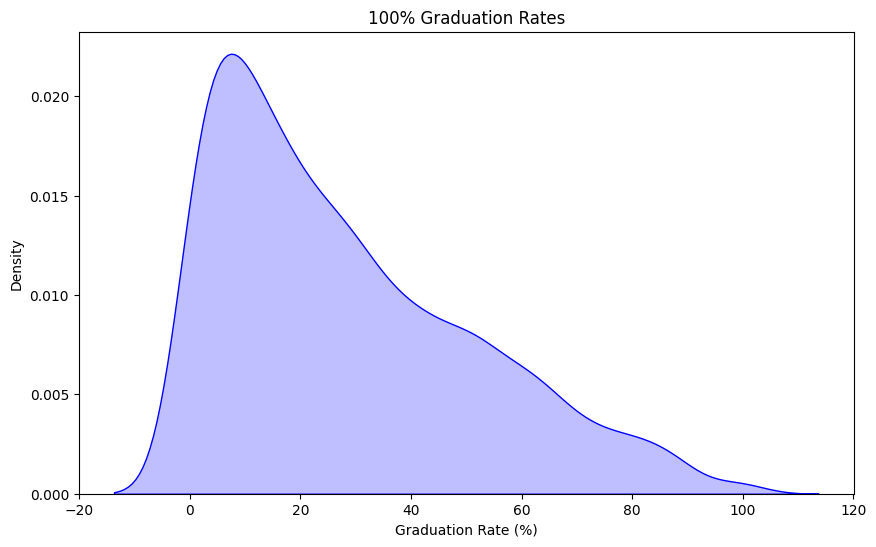

Overall Descriptive Statistics for Graduation Rates:
count    3467.000000
mean       28.364465
std        23.312730
min         0.000000
25%         9.000000
50%        22.500000
75%        43.650000
max       100.000000
Name: grad_100_value, dtype: float64


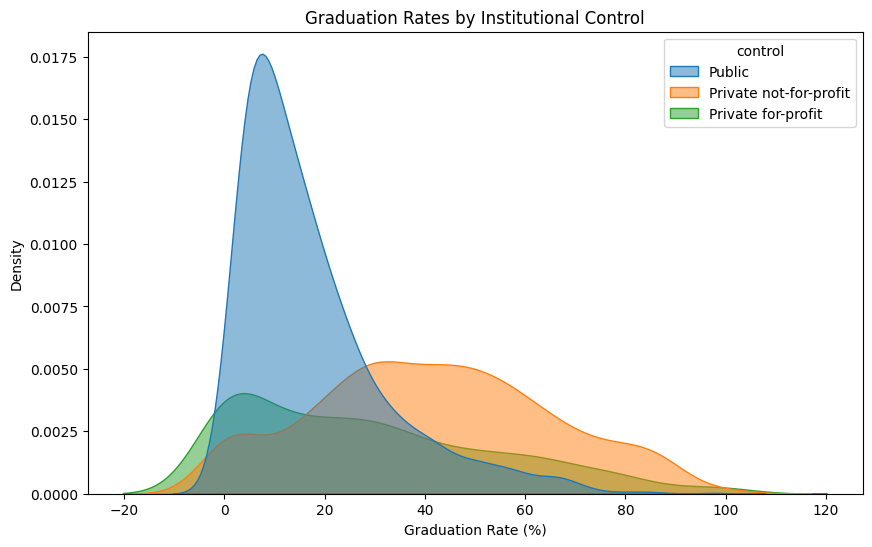


Descriptive Statistics by Institutional Control:
                         count       mean        std  min    25%   50%    75%  \
control                                                                         
Private for-profit       779.0  29.108858  25.601687  0.0   6.95  24.7  46.75   
Private not-for-profit  1189.0  41.660976  23.551231  0.0  25.00  41.0  58.30   
Public                  1499.0  17.430887  14.729443  0.0   6.90  13.2  23.25   

                          max  
control                        
Private for-profit      100.0  
Private not-for-profit  100.0  
Public                   97.8  


In [56]:
# Q5.4

# Overall Kernel Density Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(df_college['grad_100_value'], fill=True, color='blue', label='Overall')
plt.title('100% Graduation Rates')
plt.xlabel('Graduation Rate (%)')
plt.ylabel('Density')
plt.show()

# Overall Descriptive Statistics
print("Overall Descriptive Statistics for Graduation Rates:")
print(df_college['grad_100_value'].describe())

# KDE Plot Conditioned on Control
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_college, x='grad_100_value', hue='control', fill=True, alpha=0.5)
plt.title('Graduation Rates by Institutional Control')
plt.xlabel('Graduation Rate (%)')
plt.ylabel('Density')
plt.show()

# Descriptive Statistics Grouped by Control
print("\nDescriptive Statistics by Institutional Control:")
desc_by_control = df_college.groupby('control')['grad_100_value'].describe()
print(desc_by_control)

Private not-for profit colleges have the highest graduation rates, as it is the graph/line is shifted the most to the right. It also has the highest mean (41.66%) in comparison to the 2 other groups (29.1% and 17.43%, respectfully).

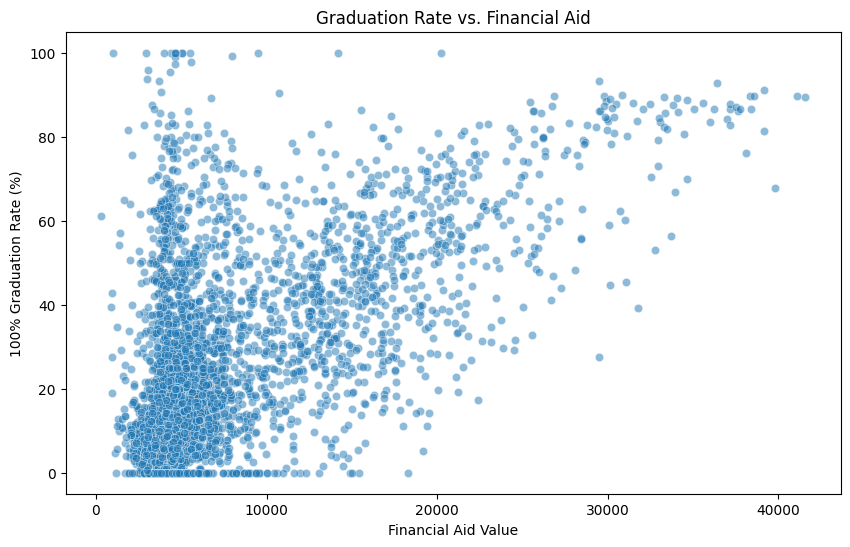

Overall Covariance: 88610.48
Overall Correlation: 0.58


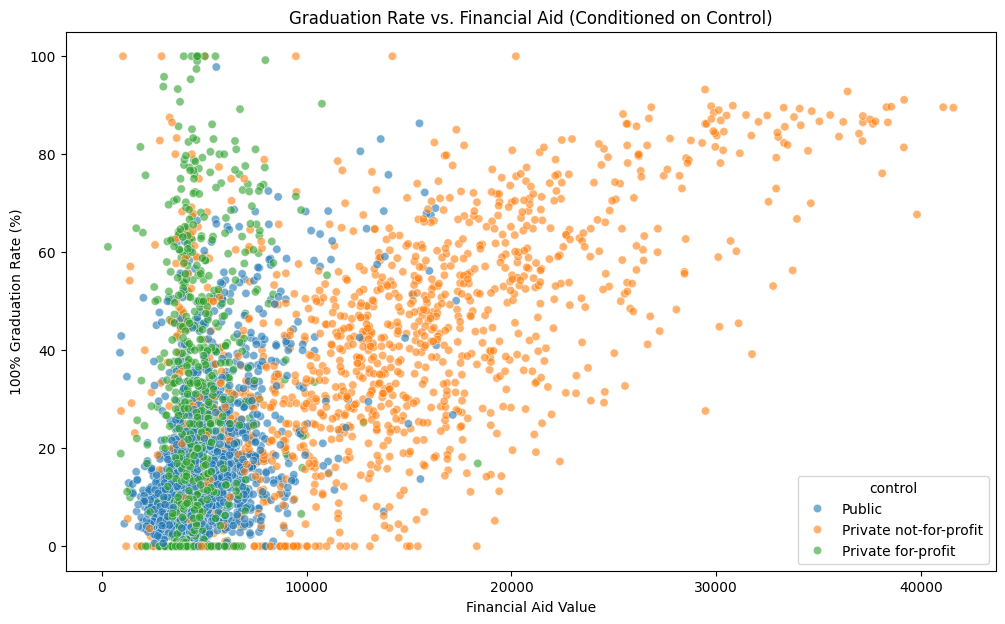


[Private for-profit]
  Covariance: 6897.52
  Correlation: 0.19

[Private not-for-profit]
  Covariance: 109274.12
  Correlation: 0.60

[Public]
  Covariance: 15355.15
  Correlation: 0.48


In [67]:
# Q5.5

df_college.columns = df_college.columns.str.strip()
df_clean = df_college.dropna(subset=['grad_100_value', 'aid_value'])

# Overall Analysis
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='aid_value', y='grad_100_value', alpha=0.5)
plt.title('Graduation Rate vs. Financial Aid')
plt.xlabel('Financial Aid Value')
plt.ylabel('100% Graduation Rate (%)')
plt.show()

# Compute overall stats
overall_cov = df_clean['aid_value'].cov(df_clean['grad_100_value'])
overall_corr = df_clean['aid_value'].corr(df_clean['grad_100_value'])

print(f"Overall Covariance: {overall_cov:.2f}")
print(f"Overall Correlation: {overall_corr:.2f}")

# Analysis by Institutional Control
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clean, x='aid_value', y='grad_100_value', hue='control', alpha=0.6)
plt.title('Graduation Rate vs. Financial Aid (Conditioned on Control)')
plt.xlabel('Financial Aid Value')
plt.ylabel('100% Graduation Rate (%)')
plt.show()

# Compute stats grouped by control
for name, group in df_clean.groupby('control'):
    cov = group['aid_value'].cov(group['grad_100_value'])
    corr = group['aid_value'].corr(group['grad_100_value'])
    print(f"\n[{name}]")
    print(f"  Covariance: {cov:.2f}")
    print(f"  Correlation: {corr:.2f}")

Based on the 2nd graph that shows an analysis of all 3 types of institutions, private not-for-profit colleges has a positive correlation with graduation rates. As Financial Aid Value increases, the Graduation Rate increases as well. This intuitively makes sense because these schools use aid to attract and retain students. Because these students don't have to work as many hours or worry as much about debt, they are more likely to stay enrolled and finish their degree on time.

**Q6.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

We're going to look at **linear transformations** of $X$, $Y = a + bX$. So we take each value of $X$, $x_i$, and transform it as $y_i = a + b x_i$.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $ \text{cov}(X,X) = s^2$.
3. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
4. Show that $\text{cov}(a+bX,a+bY) = b^2 \text{cov}(X,Y) $. Notice, this also means that $\text{cov}(bX, bX) = b^2 s^2$.
5. Suppose $b>0$ and let the median of $X$ be $\text{med}(X)$. Is it true that the median of $a+bX$ is equal to $a + b \times \text{med}(X)$? Is the IQR of $a + bX$ equal to $a + b \times \text{IQR}(X)$?
6. Show by example that the means of $X^2$ and $\sqrt{X}$ are generally not $(m(X))^2$ and $\sqrt{m(X)}$. So, the results we derived above really depend on the linearity of the transformation $Y = a + bX$, and transformations like $Y = X^2$ or $Y = \sqrt{X}$ will not behave in a similar way.

Will attach a PDF / pictures of my notebook in the repository.

**Q7.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `ames_prices.csv` dataset. The "relevant" variables for this question are:
  - `price` - Sale price value of the house
  - `Bldg.Type` - Building type of the house (single family home, end-of-unit townhome, duplex, interior townhome, two-family conversion)

1. Load the `college_completion.csv` data with Pandas.
2. Make a kernel density plot of price and compute a describe table. Now, make a kernel density plot of price conditional on building type, and use `.groupby()` to make a describe type for each type of building. Which building types are the most expensive, on average? Which have the highest variance in transaction prices?
3. Make an ECDF plot of price, and compute the sample minimum, .25 quantile, median, .75 quantile, and sample maximum (i.e. a 5-number summary).
4. Make a boxplot of price. Are there outliers? Make a boxplot of price conditional on building type. What patterns do you see?
5. Make a dummy variable indicating that an observation is an outlier.
6. Winsorize the price variable, and compute a new kernel density plot and describe table. How do the results change?

In [68]:
# Q7.1

df_college = pd.read_csv('college_completion.csv')
df_college.head()

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


In [69]:
# Q7.1

df_ames = pd.read_csv('ames_prices.csv')
df_ames.head()

,Order,PID,area,price,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,Alley,...,Screen.Porch,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition
0,1,526301100,1656,215000,20,RL,141.0,31770,Pave,NaN,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,2,526350040,896,105000,20,RH,80.0,11622,Pave,NaN,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,3,526351010,1329,172000,20,RL,81.0,14267,Pave,NaN,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,4,526353030,2110,244000,20,RL,93.0,11160,Pave,NaN,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,5,527105010,1629,189900,60,RL,74.0,13830,Pave,NaN,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


Overall Price Summary:
count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: price, dtype: float64


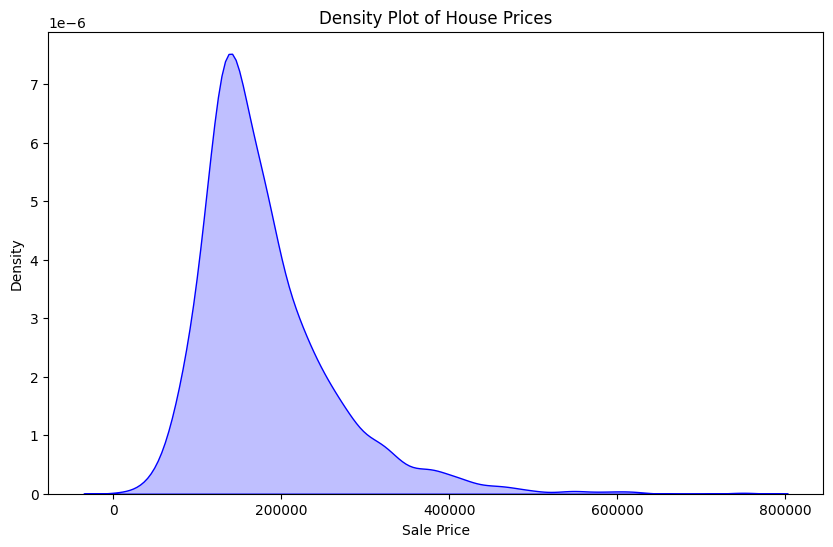


Price Summary by Building Type:
            count           mean           std      min       25%       50%  \
bldg.type                                                                     
1Fam       2425.0  184812.041237  82821.802329  12789.0  130000.0  165000.0   
2fmCon       62.0  125581.709677  31089.239840  55000.0  106562.5  122250.0   
Duplex      109.0  139808.935780  39498.973534  61500.0  118858.0  136905.0   
Twnhs       101.0  135934.059406  41938.931130  73000.0  100500.0  130000.0   
TwnhsE      233.0  192311.914163  66191.738021  71000.0  145000.0  180000.0   

                75%       max  
bldg.type                      
1Fam       220000.0  755000.0  
2fmCon     140000.0  228950.0  
Duplex     153337.0  269500.0  
Twnhs      170000.0  280750.0  
TwnhsE     222000.0  392500.0  


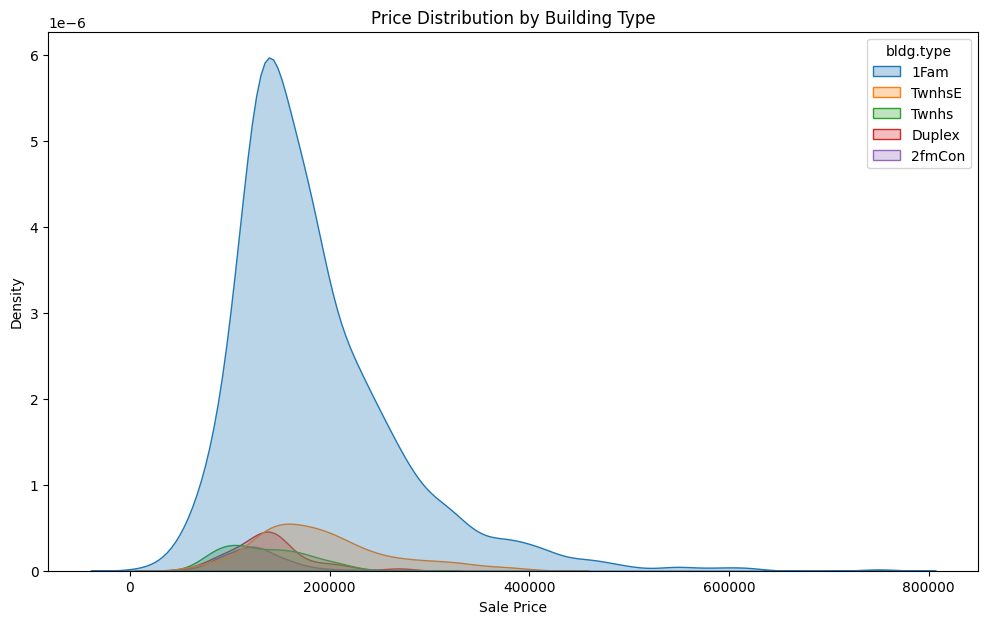

In [82]:
# Q7.2

# Overall Descriptive Table
print("Overall Price Summary:")
print(df_ames['price'].describe())

# Overall KDE Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(df_ames['price'], fill=True, color='blue')
plt.title('Density Plot of House Prices')
plt.xlabel('Sale Price')
plt.show()


# Grouped Descriptive Table
# This answers which are most expensive (mean) and most variable (std/var)
grouped_stats = df_ames.groupby('bldg.type')['price'].describe()
print("\nPrice Summary by Building Type:")
print(grouped_stats)

# KDE Plot Conditional on Building Type
plt.figure(figsize=(12, 7))
sns.kdeplot(data=df_ames, x='price', hue='bldg.type', fill=True, alpha=0.3)
plt.title('Price Distribution by Building Type')
plt.xlabel('Sale Price')
plt.show()

On average, TwnhsE (Townhouse End unit) is the most expensive building type, with a mean calculation of $192,311.

One Family buildings have the highest variance in transaction prices, with a Standard Deviation well above the rest at $82,821.

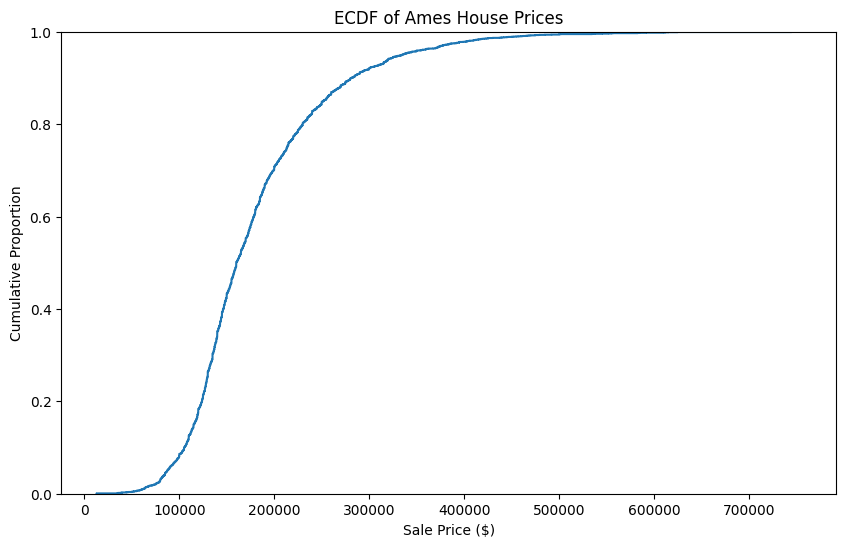

5-Number Summary:
Min        12789.0
Q1        129500.0
Median    160000.0
Q3        213500.0
Max       755000.0
Name: price, dtype: float64


In [83]:
# Q7.3

# Generate the ECDF Plot
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df_ames, x='price')
plt.title('ECDF of Ames House Prices')
plt.xlabel('Sale Price ($)')
plt.ylabel('Cumulative Proportion')
plt.show()

# Compute the 5-Number Summary
five_num = df_ames['price'].quantile([0, 0.25, 0.5, 0.75, 1.0])
five_num.index = ['Min', 'Q1', 'Median', 'Q3', 'Max']

print("5-Number Summary:")
print(five_num)


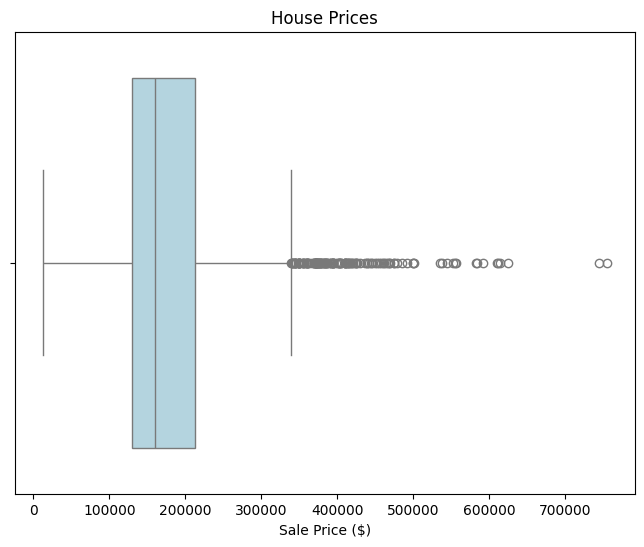

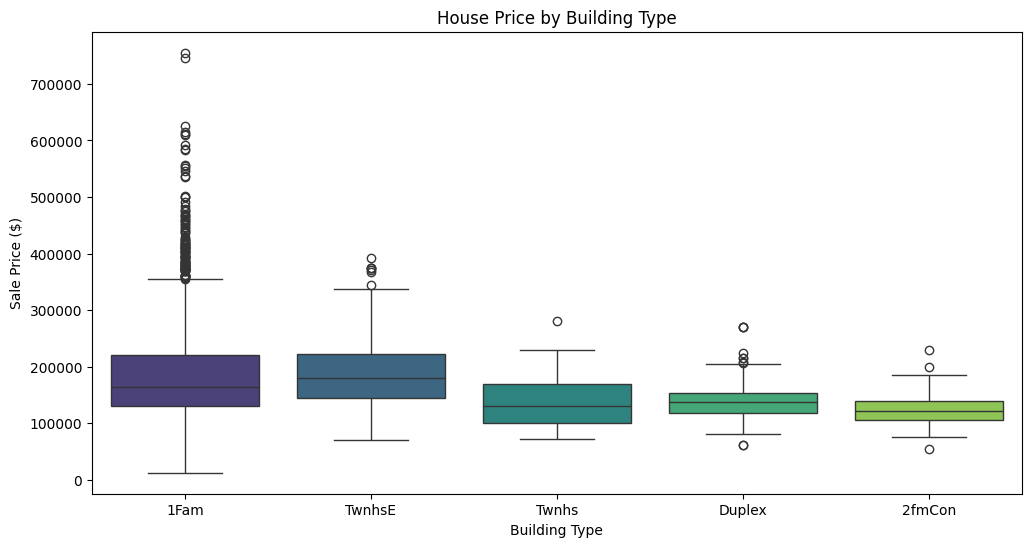

In [85]:
# Q7.4

# Overall Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_ames, x='price', color='lightblue')
plt.title('House Prices')
plt.xlabel('Sale Price ($)')
plt.show()

# Conditional Boxplot (by Building Type)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_ames, x='bldg.type', y='price', hue='bldg.type', palette='viridis', legend=False)
plt.title('House Price by Building Type')
plt.xlabel('Building Type')
plt.ylabel('Sale Price ($)')
plt.show()

For the first boxplot, there are outliers to the right of the end of the 75% Quartile line. This is demonstrating the very expensive homes in Ames that are much more expensive than a typical Ames home.

For the boxplot that analyzes prices by building type, there are a few patterns. First off, the one family building type has the highest STD and a massive spread. This is because single family homes have a large range, from small shacks to huge mansions. The Townhouse End units have the highest median and mean in comparison to all other groups, and this is shown on the graph because it is shifted slightly higher up the scale than the other building types.  

In [86]:
# Q7.5

# Calculate IQR
Q1 = df_ames['price'].quantile(0.25)
Q3 = df_ames['price'].quantile(0.75)
IQR = Q3 - Q1

# Define the bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create the dummy variable
df_ames['is_outlier'] = ((df_ames['price'] < lower_bound) | (df_ames['price'] > upper_bound)).astype(int)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print("\nOutlier Count:")
print(df_ames['is_outlier'].value_counts())

Lower Bound: 3500.0
Upper Bound: 339500.0

Outlier Count:
is_outlier
0    2793
1     137
Name: count, dtype: int64


There are 137 outliers in this dataset.

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


            Original     Winsorized
count    2930.000000    2930.000000
mean   180796.060068  177632.528669
std     79886.692357   66195.453960
min     12789.000000   87500.000000
25%    129500.000000  129500.000000
50%    160000.000000  160000.000000
75%    213500.000000  213500.000000
max    755000.000000  335000.000000


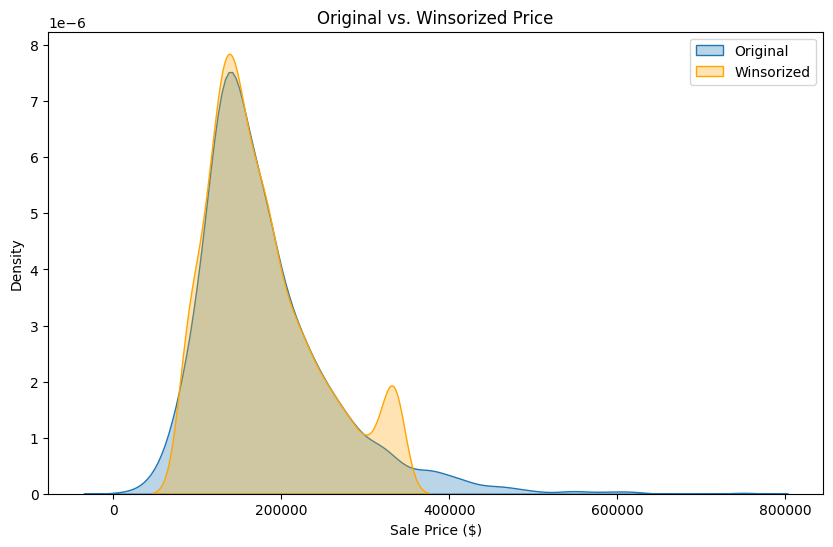

In [87]:
from scipy.stats.mstats import winsorize


# Winsorize at the 5% level (top 5% and bottom 5%)
# limits=[0.05, 0.05] takes off 5% from each tail
df_ames['price_winsorized'] = winsorize(df_ames['price'], limits=[0.05, 0.05])

# Compare the descriptive statistics
summary_comp = pd.DataFrame({
    'Original': df_ames['price'].describe(),
    'Winsorized': df_ames['price_winsorized'].describe()
})
print(summary_comp)

# New KDE Plot Comparison
plt.figure(figsize=(10, 6))
sns.kdeplot(df_ames['price'], label='Original', fill=True, alpha=0.3)
sns.kdeplot(df_ames['price_winsorized'], label='Winsorized', fill=True, alpha=0.3, color='orange')
plt.title('Original vs. Winsorized Price')
plt.xlabel('Sale Price ($)')
plt.legend()
plt.show()

The winsorized price cuts off the bottom and top 5%, so the graph condenses slightly and there is a taller spike. The Standard Deviation shrinks, the minimum increases, and the maximum decreases. The mean will also shift closer to the median. The originial data's outliers were pulling the mean up, but winsorizing fixes this by creating a more central representation.